# Interactive 3D moving-source bearings

The station estimates bearing only. Ray length uses true range **for visualization only**; no estimated 3D point and no tracking filter are shown. Play/Pause changes independent frames, and view sliders rotate the scene.

In [1]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
PROJECT_ROOT=Path.cwd()
if PROJECT_ROOT.name=='notebooks': PROJECT_ROOT=PROJECT_ROOT.parent
sys.path.insert(0,str(PROJECT_ROOT))
from model.geometry import comparison_arrays, array_centroid, direction_vector
from simulation.moving_source import simulate_moving_source
from simulation.signals import deterministic_bandlimited_signal
from simulation.trajectory import ConstantVelocityTrajectory
from validation.moving_source_study import estimate_independent_frame, frame_truth_at_reception
from visualization.moving_scene import MovingSceneFrame, plot_moving_scene_frame, interactive_moving_scene

In [2]:
fs=48000.0; c=343.0; frame_length=512; snr_db=10.0
positions=comparison_arrays()['tetrahedral']; centroid=array_centroid(positions)
u0=direction_vector(np.deg2rad(45),np.deg2rad(30)); tangent=np.cross([0,0,1],u0); tangent=tangent/np.linalg.norm(tangent)
trajectory=ConstantVelocityTrajectory(centroid+25*u0,20*tangent)
source_start=-0.5; source=deterministic_bandlimited_signal(fs,1.0,minimum_frequency_hz=300,maximum_frequency_hz=10000,tone_count=41,taper_fraction=.1)
emission_centers=np.linspace(-.12,.12,13); rng=np.random.default_rng(20260830); frames=[]
for index, te_center in enumerate(emission_centers):
    q=trajectory.q(te_center); receive_center=te_center+np.linalg.norm(q-centroid)/c
    reception=receive_center+(np.arange(frame_length)-.5*(frame_length-1))/fs
    propagation=simulate_moving_source(source,fs,positions,trajectory,source_start_time_s=source_start,reception_times_s=reception)
    noise_scale=np.sqrt(np.mean(propagation.channels**2))/10**(snr_db/20)
    estimates=estimate_independent_frame(propagation.channels+rng.normal(0,noise_scale,propagation.channels.shape),positions,fs)
    truth=frame_truth_at_reception(receive_center,positions,trajectory)
    frames.append(MovingSceneFrame(index,receive_center,truth.source_position_m,truth.direction,estimates['reference_3_gcc_wls']['direction'],estimates['all_6_equal_gcc_wls']['direction'],estimates['equal_weight_srp_phat']['direction'],20.0,np.linalg.norm(truth.source_position_m-centroid),snr_db))
path=trajectory.q(np.linspace(-.16,.16,200))
assert len(frames)==13 and all(np.all(np.isfinite(f.srp_direction)) for f in frames)
print('independent frames:',len(frames),'maximum displayed angular error, deg:',max(max(f.angular_errors_deg().values()) for f in frames))

independent frames: 13 maximum displayed angular error, deg: 0.4546729331922665


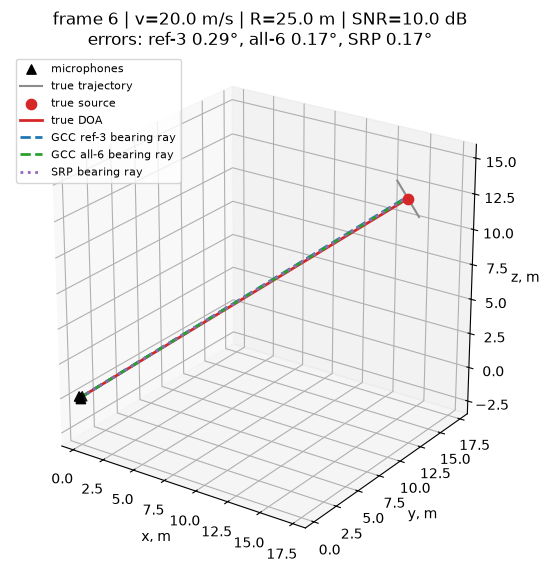

In [3]:
fig=plt.figure(figsize=(8.5,6.5)); ax=fig.add_subplot(111,projection='3d')
plot_moving_scene_frame(ax,positions,path,frames[len(frames)//2]); plt.show()

In [4]:
widget=interactive_moving_scene(positions,path,frames);